In [6]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [7]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Reproducibility
np.random.seed(42)

In [8]:
ds = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [9]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [ ]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_truth = ds.sortby("latitude")  # ensure south → north

tr_lons = ds_truth.longitude.values
tr_lats = ds_truth.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
)
ds_fc = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-8)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

# Keep names expected by your next cells
ds_pp_lr = ds_fc
ds_pp_hr = ds_tr
# ...existing code...

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [11]:
ds_pp_lr

<xarray.Dataset> Size: 90MB
Dimensions:                   (time: 7304, latitude: 24, longitude: 32)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 96B -13.5 -12.0 ... 19.5 21.0
  * longitude                 (longitude) float32 128B 90.0 91.5 ... 135.0 136.5
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 22MB -6.866...
    10m_v_component_of_wind   (time, latitude, longitude) float32 22MB 3.512 ...
    2m_temperature            (time, latitude, longitude) float32 22MB 299.5 ...
    total_precipitation_24hr  (time, latitude, longitude) float32 22MB 0.0006...
Attributes:
    regrid_method:  bilinear

In [12]:
ds_pp_hr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

## Check Missing Value

In [13]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_pp_lr, "Forecast (Low-res)")
check_nan_summary(ds_pp_hr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [14]:
ds_pred = ds_pp_lr
ds_tar = ds_pp_hr

In [15]:
import numpy as np
import tensorflow as tf

# ==========================================
# 1️⃣ Variable stacking (NHWC: Time, Lat, Lon, Channel)
# ==========================================
vars_list = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]

# Extract and stack predictors directly
X = np.stack(
    [ds_pred[v].values for v in vars_list],
    axis=-1  
)

# Extract and stack targets directly
Y = np.stack(
    [ds_tar[v].values for v in vars_list],
    axis=-1  
)

print("Data shapes (Batch, Height, Width, Channels):")
print("X shape:", X.shape)  # Result: (7300, 45, 50, 4)
print("Y shape:", Y.shape)  # Result: (7300, 45, 50, 4)

# ==========================================
# 1.5️⃣ Log-transform precipitation (heavily right-skewed)
# ==========================================
TP_IDX = vars_list.index("total_precipitation_24hr")
X[..., TP_IDX] = np.log1p(np.clip(X[..., TP_IDX], 0, None))
Y[..., TP_IDX] = np.log1p(np.clip(Y[..., TP_IDX], 0, None))

# ==========================================
# 2️⃣ Train / Val / Test split (80 / 10 / 10)
# ==========================================
N = X.shape[0]
train_end = int(0.8 * N)
val_end   = int(0.9 * N)

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

Y_train = Y[:train_end]
Y_val   = Y[train_end:val_end]
Y_test  = Y[val_end:]

print(f"\nSplit sizes (N={N}):")
print(f"  Train : {len(X_train)}")
print(f"  Val   : {len(X_val)}")
print(f"  Test  : {len(X_test)}")

2026-03-31 07:34:29.550081: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 07:34:29.607179: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 07:34:29.607196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 07:34:29.608169: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 07:34:29.615069: I tensorflow/core/platform/cpu_feature_guar

Data shapes (Batch, Height, Width, Channels):
X shape: (7304, 24, 32, 4)
Y shape: (7304, 144, 192, 4)

Split sizes (N=7304):
  Train : 5843
  Val   : 730
  Test  : 731


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ==============================
# Normalize with separate stats (X vs Y)
# ==============================
X_mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
X_std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-6

Y_mean = Y_train.mean(axis=(0, 1, 2), keepdims=True)
Y_std  = Y_train.std(axis=(0, 1, 2), keepdims=True) + 1e-6

X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

Y_train = (Y_train - Y_mean) / Y_std
Y_val   = (Y_val   - Y_mean) / Y_std
Y_test  = (Y_test  - Y_mean) / Y_std

# rebuild tf.data after normalization
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   Y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test,  Y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ==============================
# SR model that auto-matches X->Y spatial size
# ==============================
h_in, w_in, c_in = X_train.shape[1], X_train.shape[2], X_train.shape[3]
h_out, w_out, c_out = Y_train.shape[1], Y_train.shape[2], Y_train.shape[3]

if (h_out % h_in != 0) or (w_out % w_in != 0):
    raise ValueError(f"Y spatial size must be integer multiple of X. X=({h_in},{w_in}), Y=({h_out},{w_out})")

scale_h = h_out // h_in
scale_w = w_out // w_in

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
    return x

inp = layers.Input(shape=(h_in, w_in, c_in))

# feature extraction at LR
x = conv_block(inp, 64)
x = conv_block(x, 64)

# upsample to target size
x = layers.UpSampling2D(size=(scale_h, scale_w), interpolation="bilinear")(x)
x = conv_block(x, 64)
x = conv_block(x, 32)

# output channels must match Y channels
out = layers.Conv2D(c_out, 1, padding="same", activation="linear")(x)

model = Model(inp, out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"],
)

model.summary()

2026-03-31 07:34:45.850331: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 07:34:45.911704: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 07:34:45.913124: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24, 32, 4)]       0         
                                                                 
 conv2d (Conv2D)             (None, 24, 32, 64)        2368      
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 32, 64)        36928     
                                                                 
 conv2d_2 (Conv2D)           (None, 24, 32, 64)        36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 32, 64)        36928     
                                                                 
 up_sampling2d (UpSampling2  (None, 144, 192, 64)      0         
 D)                                                              
                                                             

In [17]:
# ==============================
# Early stopping + train
# ==============================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_sr_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100


2026-03-31 07:34:52.530789: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-03-31 07:34:52.673750: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-31 07:34:53.010478: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-31 07:34:53.557916: I external/local_xla/xla/service/service.cc:168] XLA service 0x76f16a8d12c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-31 07:34:53.557937: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-03-31 07:34:53.562948: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774942493.655524     375 device_co

366/366 [==============================] - 11s 18ms/step - loss: 0.2825 - mae: 0.3030 - val_loss: 0.1116 - val_mae: 0.1971 - lr: 0.0010
Epoch 2/100
366/366 [==============================] - 6s 15ms/step - loss: 0.1079 - mae: 0.1825 - val_loss: 0.0951 - val_mae: 0.1680 - lr: 0.0010
Epoch 3/100
366/366 [==============================] - 6s 15ms/step - loss: 0.0986 - mae: 0.1689 - val_loss: 0.0968 - val_mae: 0.1737 - lr: 0.0010
Epoch 4/100
366/366 [==============================] - 6s 15ms/step - loss: 0.0937 - mae: 0.1617 - val_loss: 0.0873 - val_mae: 0.1590 - lr: 0.0010
Epoch 5/100
366/366 [==============================] - 6s 15ms/step - loss: 0.0912 - mae: 0.1585 - val_loss: 0.0857 - val_mae: 0.1588 - lr: 0.0010
Epoch 6/100
366/366 [==============================] - 6s 15ms/step - loss: 0.0890 - mae: 0.1557 - val_loss: 0.1014 - val_mae: 0.1916 - lr: 0.0010
Epoch 7/100
366/366 [==============================] - 6s 15ms/step - loss: 0.0875 - mae: 0.1540 - val_loss: 0.0826 - val_mae: 0.

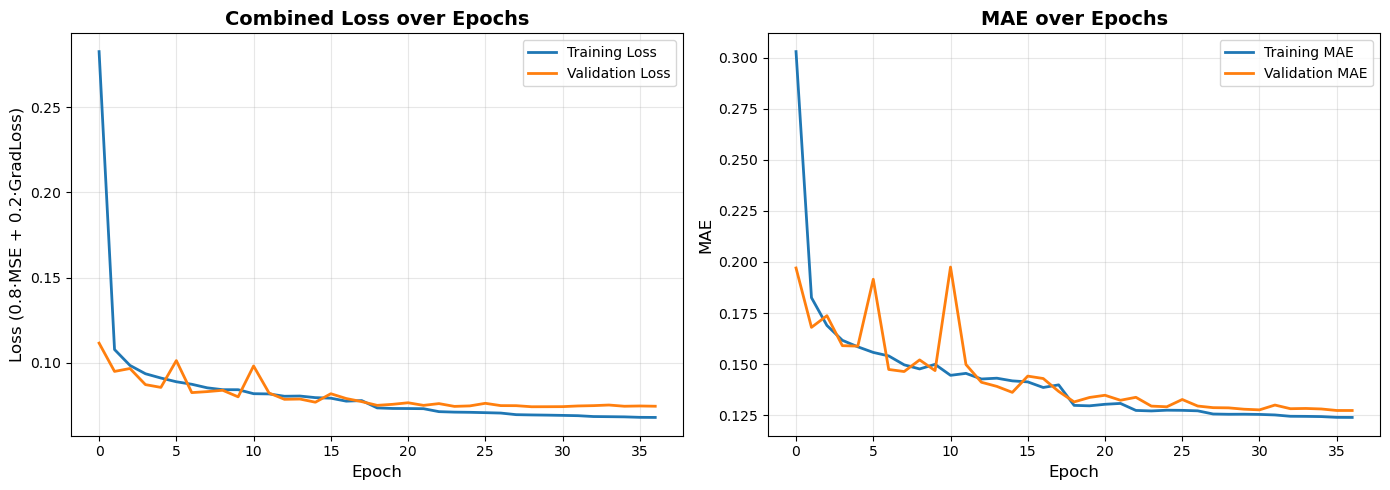


Final Training Loss: 0.068095
Final Validation Loss: 0.074655
Final Training MAE: 0.123921
Final Validation MAE: 0.127316


In [18]:
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss (combined = 0.8*MSE + 0.2*gradient_loss)
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (0.8·MSE + 0.2·GradLoss)', fontsize=12)
ax1.set_title('Combined Loss over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: MAE metric
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('MAE over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")
print(f"Final Training MAE: {history.history['mae'][-1]:.6f}")
print(f"Final Validation MAE: {history.history['val_mae'][-1]:.6f}")

/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


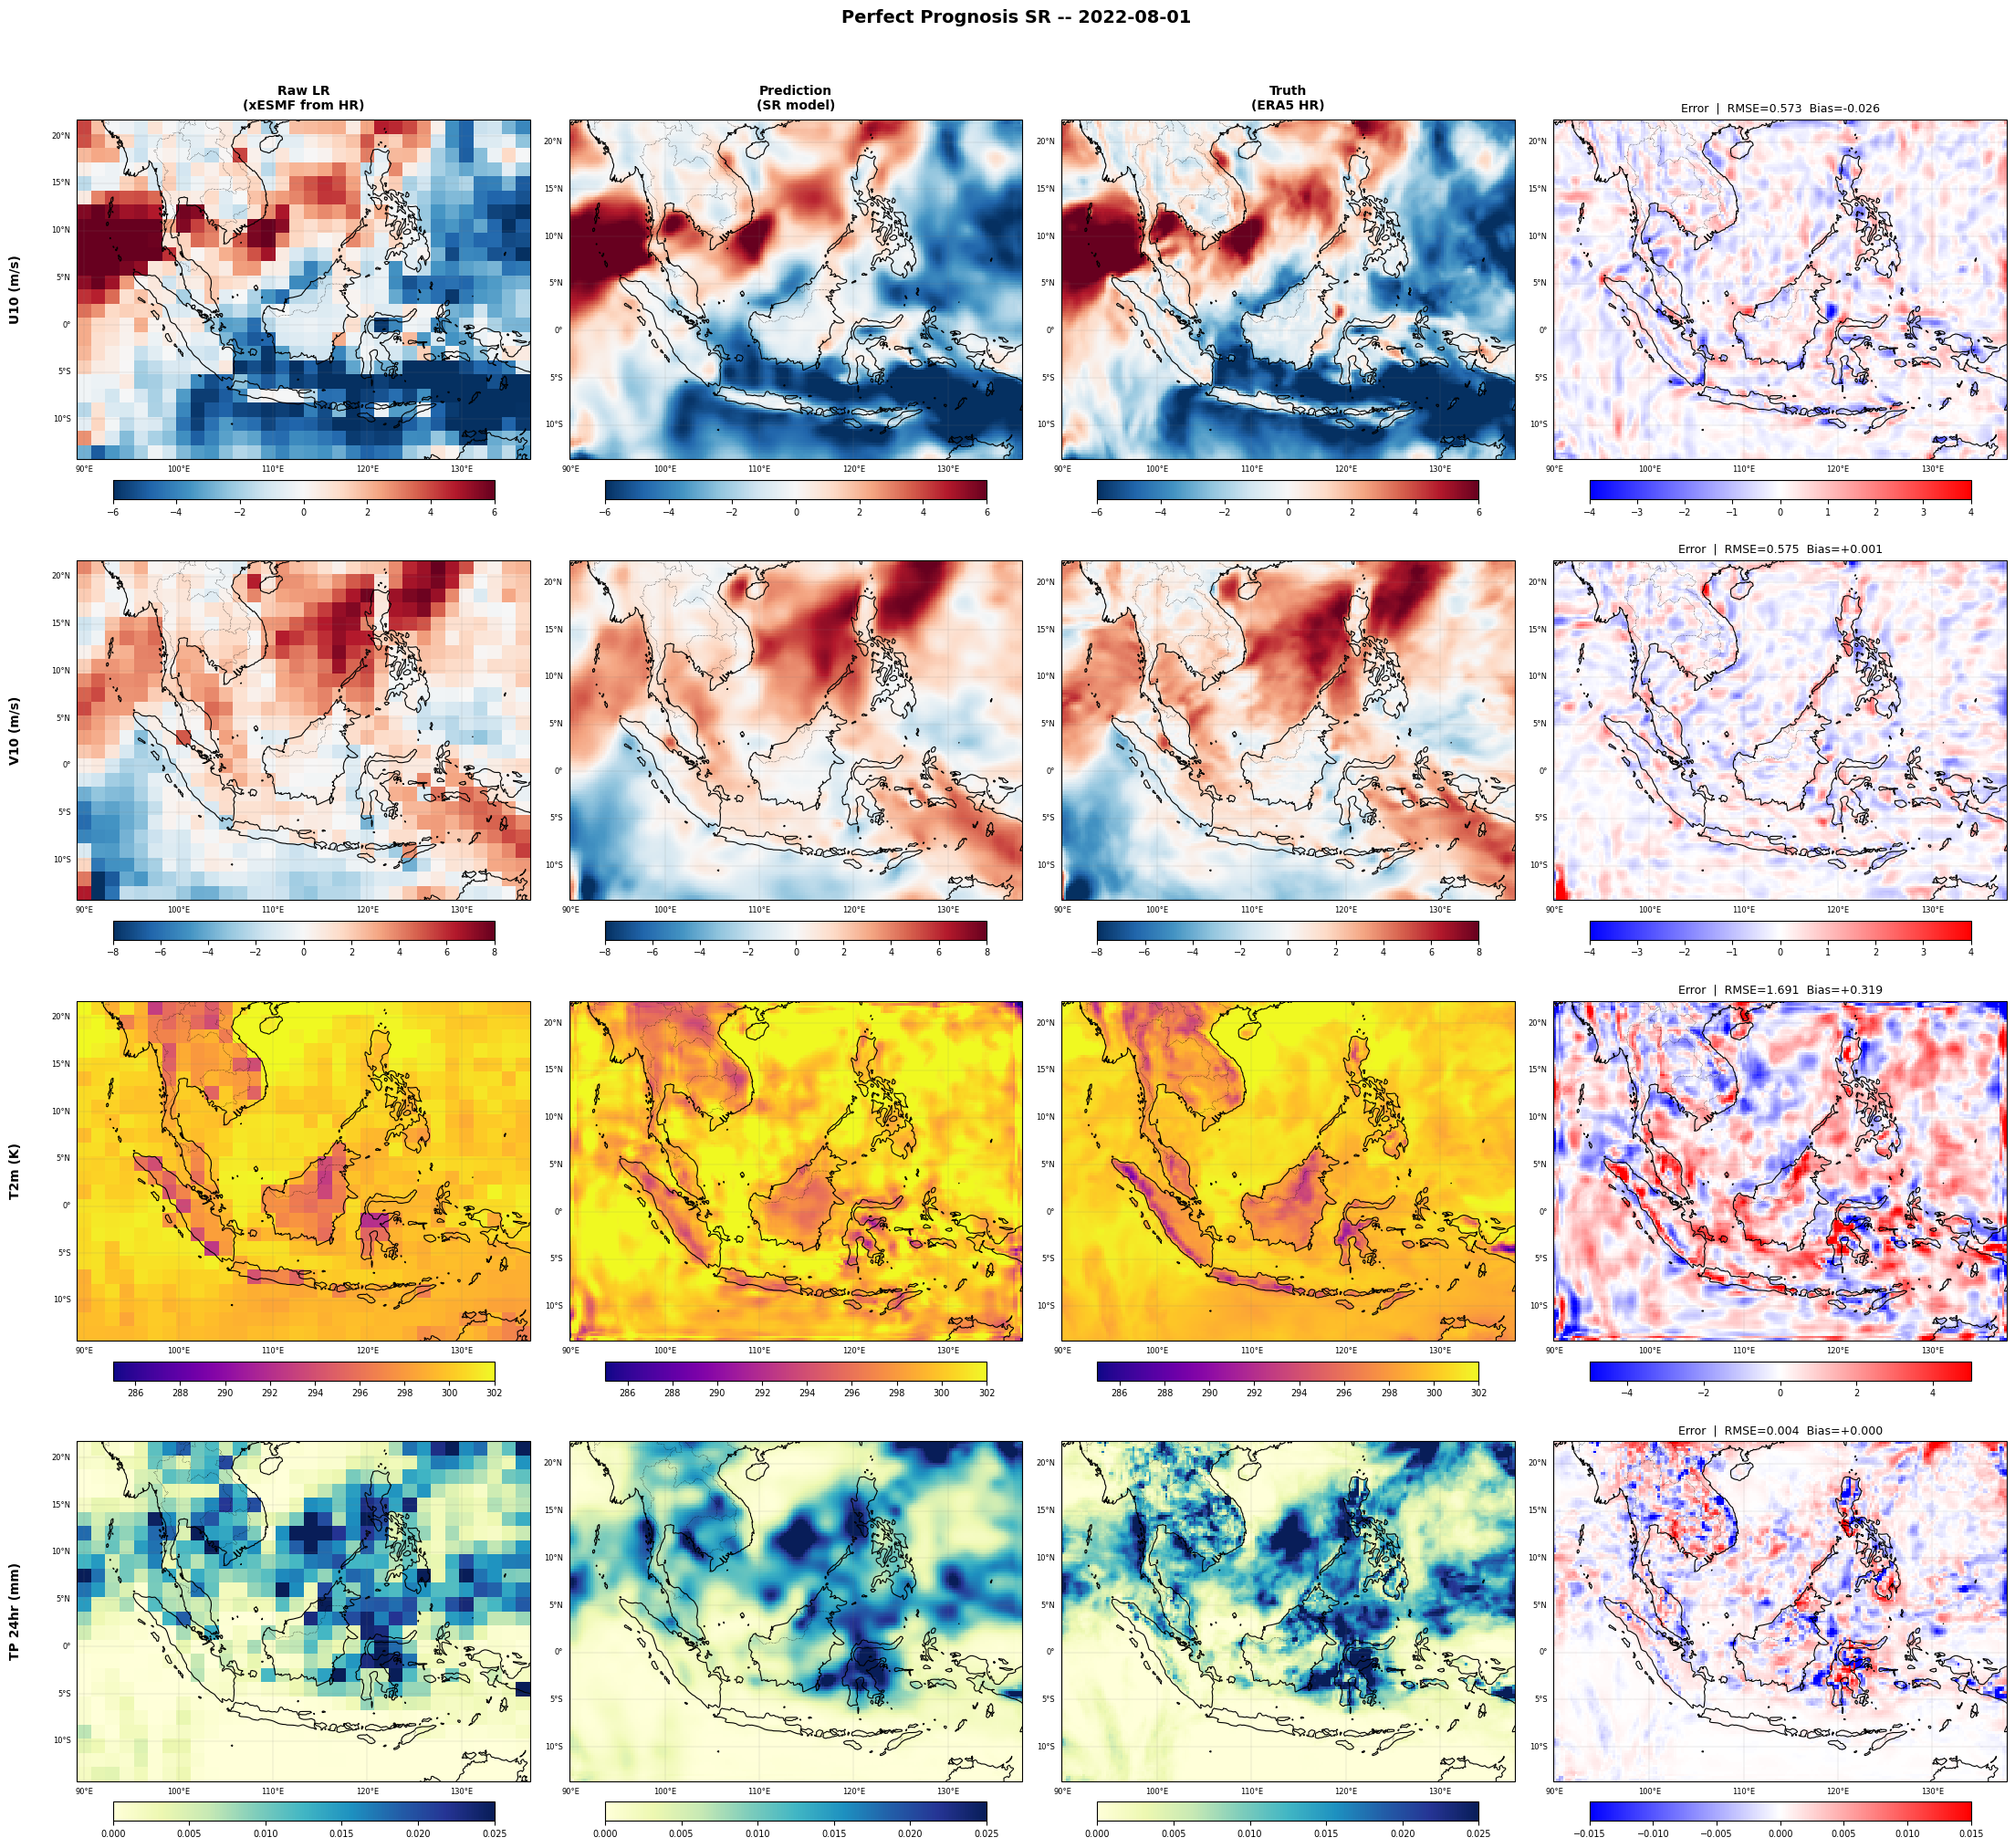

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
VAR_KEYS   = vars_list  # from your stacking cell

target_date = np.datetime64("2022-08-01")

# Hardcoded color ranges
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Test-time index mapping (test starts at val_end)
test_times = ds_pp_hr.time.values[val_end:]
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(f"{target_date} not found in test set.")
idx = int(idx[0])

# Raw low-res input (physical units) at same test sample
raw_fc = np.stack(
    [ds_pp_lr[v].isel(time=val_end + idx).values for v in VAR_KEYS],
    axis=-1
).astype(np.float32)

# Safety transpose check
if raw_fc.shape[0] == len(ds_pp_lr.longitude) and raw_fc.shape[1] == len(ds_pp_lr.latitude):
    raw_fc = raw_fc.transpose(1, 0, 2)

lats_lr = ds_pp_lr.latitude.values
lons_lr = ds_pp_lr.longitude.values

# Denormalize helper (reverses z-score AND log1p on precipitation)
def denormalize(arr, mu, sig, tp_idx=TP_IDX):
    out = arr * sig + mu
    out[..., tp_idx] = np.expm1(out[..., tp_idx])
    return out

# Use normalization stats from training cell
# X_mean, X_std, Y_mean, Y_std are shape (1,1,1,C)
x_norm    = X_test[idx]
y_norm    = Y_test[idx]
pred_norm = model.predict(x_norm[np.newaxis], verbose=0)[0]

y_plot    = denormalize(y_norm.copy(),    Y_mean.squeeze(), Y_std.squeeze())
pred_plot = denormalize(pred_norm.copy(), Y_mean.squeeze(), Y_std.squeeze())

# Safety transpose check
if pred_plot.shape[0] == len(ds_pp_hr.longitude) and pred_plot.shape[1] == len(ds_pp_hr.latitude):
    y_plot    = y_plot.transpose(1, 0, 2)
    pred_plot = pred_plot.transpose(1, 0, 2)

lats_hr = ds_pp_hr.latitude.values
lons_hr = ds_pp_hr.longitude.values

proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS)

col_titles = [
    "Raw LR\n(xESMF from HR)",
    "Prediction\n(SR model)",
    "Truth\n(ERA5 HR)",
    "Error\n(Pred - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    raw_v  = raw_fc[..., v]
    pred_v = pred_plot[..., v]
    true_v = y_plot[..., v]
    err_v  = pred_v - true_v

    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmaps_field[v], vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmaps_field[v], vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmaps_field[v], vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",          -elim, elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]
        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="auto",
            transform=proj,
        )

        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(
                -0.15, 0.5, VAR_LABELS[v],
                transform=ax.transAxes,
                fontsize=10, fontweight="bold", va="center", rotation=90
            )

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}", fontsize=9, pad=6)

fig.suptitle(
    f"Perfect Prognosis SR -- {str(target_date)[:10]}",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"pp_sr_eval_full_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
from scipy.stats import pearsonr
import numpy as np
import tensorflow as tf

# Use same labels/order as training
VARS = vars_list
if "VAR_LABELS" not in globals():
    VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

# Predict on entire test set (normalized space)
y_pred_norm = model.predict(test_ds, verbose=1)

print(f"y_pred_norm shape: {y_pred_norm.shape}")
print(f"Y_test shape:      {Y_test.shape}")

# Denormalize helper (reverses z-score AND log1p on precipitation)
def denormalize(arr, mu, sig, tp_idx=TP_IDX):
    out = arr * sig + mu
    out[..., tp_idx] = np.expm1(out[..., tp_idx])
    return out

# Denormalize predictions and truth to physical units
y_pred_phys = denormalize(y_pred_norm, Y_mean.squeeze(), Y_std.squeeze())
y_true_phys = denormalize(Y_test.copy(), Y_mean.squeeze(), Y_std.squeeze())

# Baseline: bilinear upsample low-res input (physical units) to HR size
x_lr_phys = denormalize(X_test.copy(), X_mean.squeeze(), X_std.squeeze())  # (N, Hlr, Wlr, C)
h_out, w_out = y_true_phys.shape[1], y_true_phys.shape[2]
x_base_phys = tf.image.resize(x_lr_phys, size=(h_out, w_out), method="bilinear").numpy()

print("\n" + "=" * 100)
print(f"{'Variable':30s} | {'RMSE':>8s} | {'MAE':>8s} | {'Bias':>8s} | {'Corr':>8s} | {'Baseline RMSE':>14s} | {'Skill':>8s}")
print("=" * 100)

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[..., v_idx]
    true_v = y_true_phys[..., v_idx]
    base_v = x_base_phys[..., v_idx]

    # Remove NaNs without flattening
    mask = ~(np.isnan(pred_v) | np.isnan(true_v) | np.isnan(base_v))
    pred_v = np.where(mask, pred_v, np.nan)
    true_v = np.where(mask, true_v, np.nan)
    base_v = np.where(mask, base_v, np.nan)

    rmse = np.nanmean(np.sqrt(np.nanmean((pred_v - true_v) ** 2, axis=(1, 2))))
    mae  = np.nanmean(np.nanmean(np.abs(pred_v - true_v), axis=(1, 2)))
    bias = np.nanmean(np.nanmean(pred_v - true_v, axis=(1, 2)))

    p_mean = np.nanmean(pred_v, axis=(1, 2), keepdims=True)
    t_mean = np.nanmean(true_v, axis=(1, 2), keepdims=True)
    p_anom = pred_v - p_mean
    t_anom = true_v - t_mean
    num = np.nansum(p_anom * t_anom, axis=(1, 2))
    den = np.sqrt(np.nansum(p_anom ** 2, axis=(1, 2)) * np.nansum(t_anom ** 2, axis=(1, 2)))
    corr_per = np.divide(num, den, out=np.full_like(num, np.nan, dtype=np.float64), where=den > 0)
    corr = np.nanmean(corr_per)

    rmse_base = np.nanmean(np.sqrt(np.nanmean((base_v - true_v) ** 2, axis=(1, 2))))
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    label = VAR_LABELS[v_idx] if v_idx < len(VAR_LABELS) else v_name
    print(f"{label:30s} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means model improves over bilinear-upsample baseline.")

46/46 [==============================] - 0s 7ms/step
y_pred_norm shape: (731, 144, 192, 4)
Y_test shape:      (731, 144, 192, 4)

Variable                       |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)                      |   0.6719 |   0.4629 |  -0.0278 |   0.9842 |         1.2789 |  +0.4746
V10 (m/s)                      |   0.6453 |   0.4472 |  -0.0249 |   0.9734 |         1.1332 |  +0.4306
T2m (K)                        |   2.0696 |   1.4916 |  +0.4340 |   0.5963 |         1.2106 |  -0.7096
TP 24hr (mm)                   |   0.0051 |   0.0023 |  -0.0001 |   0.8970 |         0.0073 |  +0.2964

Skill > 0 means model improves over bilinear-upsample baseline.
